<img align="left" width="350" height="70" src="https://gsb.skku.edu/_res/en/img/common/logo_eng.png"> <br><br><br>

# **Data Wrangling: Join, Combine, and Reshape**

Based on
**Programming for Analytics by Yuan Tian**

---

In some applications, data may be stored in multiple datasets or databases. This lecture focuses on data combining, merging, and rearranging techniques.

**Objective**
* Combining and merging datasets


**Reference**

W. McKinney, [Python for Data Analysis: Data Wrangling with Pandas, NumPy, and IPython](https://wesmckinney.com/book/), 3 edition. O’Reilly Media, 2022
* **Chapter 8**: [Data Wrangling: Join, Combine, and Reshape](https://wesmckinney.com/book/data-wrangling.html)

---


## **Initial Prep**

Download the `rexon_metal.db` database file from iCampus and save it to your `data/` directory.



In [2]:
import pandas as pd
import numpy as np
# we will need to import sqlite3, a package to work with sqlite databases.
import sqlite3

## Read Data from Relational Database


In [5]:
# Read sqlite query results into a pandas DataFrame
# establish a connection with sqlite3 database
# copy the file path for the "rexon_metal.db"

filepath = "data\\rexon_metals.db"
con = sqlite3.connect(filepath)

# fetch all the data from the tables in the database, and save the data in dataframes.
CUSTOMER_ORDER = pd.read_sql_query("SELECT * from CUSTOMER_ORDER", con)
CUSTOMER = pd.read_sql_query("SELECT * from CUSTOMER", con)
PRODUCT = pd.read_sql_query("SELECT * from PRODUCT", con)

# close the db connection.
con.close()

In [6]:
# Verify that result of SQL query is stored in the dataframe
CUSTOMER_ORDER
# primary key (unique id) is order_id

,ORDER_ID,ORDER_DATE,SHIP_DATE,CUSTOMER_ID,PRODUCT_ID,ORDER_QTY,SHIPPED
0,1,2015-05-15,2015-05-18,1,1,450,false
1,2,2015-05-18,2015-05-21,3,2,600,false
2,3,2015-05-20,2015-05-23,3,5,300,false
3,4,2015-05-18,2015-05-22,5,4,375,false
4,5,2015-05-17,2015-05-20,3,2,500,false


In [7]:
PRODUCT # primary key is product_id

,PRODUCT_ID,DESCRIPTION,PRICE
0,1,Copper,7.51
1,2,Aluminum,2.58
2,3,Silver,15.00
3,4,Steel,12.31
4,5,Bronze,4.00
5,6,Duralumin,7.60
6,7,Solder,14.16
7,8,Stellite,13.31
8,9,Brass,4.75


In [8]:
CUSTOMER # primary key is customer_id

,CUSTOMER_ID,NAME,REGION,STREET_ADDRESS,CITY,STATE,ZIP
0,1,LITE Industrial,Southwest,729 Ravine Way,Irving,TX,75014
1,2,Rex Tooling Inc,Southwest,6129 Collie Blvd,Dallas,TX,75201
2,3,Re-Barre Construction,Southwest,9043 Windy Dr,Irving,TX,75032
3,4,Prairie Construction,Southwest,264 Long Rd,Moore,OK,62104
4,5,Marsh Lane Metal Works,Southeast,9143 Marsh Ln,Avondale,LA,79782


## **DataFrame Joins (Database-Style)**

Data contained in pandas objects can be combined together in a number of ways. The following functions are for dataframe joins with slightly different syntax.

**General function:**

* [`pandas.merge(left, right)`](https://pandas.pydata.org/docs/reference/api/pandas.merge.html?highlight=pandas%20merge#pandas.merge): Connect rows in DataFrames based on one or more keys. This will be familiar to users of SQL or other relational databases, as it implements database join operations.
    * `how = inner` (**default**): type of merge performed include `left`, `right`, `outer`, `inner`, and `cross`.
    * `on = `: key column or index level names to join on. The key column name **must be the same** in both DataFrames.
    * `left_on = ` and `right_on = `: label or list. Use when the **key columns have different names** in the DataFrames.
    * `validate = `: string, optional. If specified, checks if merge is of specified type:
        * `"one_to_one"` or `"1:1"`: check if merge keys are unique in both left and right datasets.
        * `"one_to_many"` or `"1:m"`: check if merge keys are unique in left dataset. `"one_to_many"` includes `"one_to_one"`.
        * `"many_to_one"` or `"m:1"`: check if merge keys are unique in right dataset.
        * `"many_to_many"` or `"m:m"`: allowed, but **does not** result in checks.


**DataFrame functions:**
* [`DataFrame.merge(right)`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.merge.html): Merge DataFrame or named Series objects with a database-style join.



### Inner Join (the default join)

When joining two datasets, an inner join will return the result set where the joining keys have a matching value. All rows with **non-matching key values will be <font color="red">excluded</font> from the result set**.



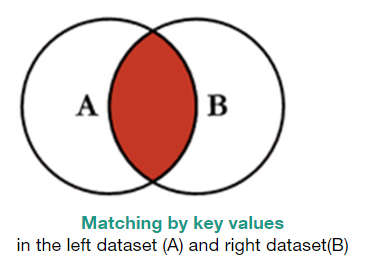

Suppose we want to merge the CUSTOMER and CUSTOMER_ORDER table, and display the order details and customer name in one result table.

In [27]:
# CUSTOMER table contains an unique list of customers.
CUSTOMER

,CUSTOMER_ID,NAME,REGION,STREET_ADDRESS,CITY,STATE,ZIP
0,1,LITE Industrial,Southwest,729 Ravine Way,Irving,TX,75014
1,2,Rex Tooling Inc,Southwest,6129 Collie Blvd,Dallas,TX,75201
2,3,Re-Barre Construction,Southwest,9043 Windy Dr,Irving,TX,75032
3,4,Prairie Construction,Southwest,264 Long Rd,Moore,OK,62104
4,5,Marsh Lane Metal Works,Southeast,9143 Marsh Ln,Avondale,LA,79782


In [47]:
# CUSTOMER dataframe contains a unique list of customers.
# check for uniqueness of customers, series.nunique() or series.unique()
CUSTOMER['CUSTOMER_ID'].nunique() == CUSTOMER.shape[0]

True

In [51]:
len(CUSTOMER)

5

In [48]:
CUSTOMER_ORDER

,ORDER_ID,ORDER_DATE,SHIP_DATE,CUSTOMER_ID,PRODUCT_ID,ORDER_QTY,SHIPPED
0,1,2015-05-15,2015-05-18,1,1,450,false
1,2,2015-05-18,2015-05-21,3,2,600,false
2,3,2015-05-20,2015-05-23,3,5,300,false
3,4,2015-05-18,2015-05-22,5,4,375,false
4,5,2015-05-17,2015-05-20,3,2,500,false


In [30]:
CUSTOMER_ORDER['CUSTOMER_ID'].nunique() == CUSTOMER_ORDER.shape[0]
#false, it means that the customer_id in the order table is not unique, there are duplicates.

False

In [52]:
# inner join the dataframes using the key columns "customer_id"
# default: inner join, one-to-many ("1:m")
# the key column (CUSTOMER_ID) in the CUSTOMER dataframe is unique.
# the key column (CUSTOMER_ID)  in the CUSTOMER_ORDER dataframe has duplicates.
# so the relationship should be one to many.
pd.merge(CUSTOMER[["CUSTOMER_ID","NAME", "REGION"]], # left table/dataframe
         CUSTOMER_ORDER, # right table/dataframe
         how = "inner",
         on="CUSTOMER_ID",
         validate ="1:m")

,CUSTOMER_ID,NAME,REGION,ORDER_ID,ORDER_DATE,SHIP_DATE,PRODUCT_ID,ORDER_QTY,SHIPPED
0,1,LITE Industrial,Southwest,1,2015-05-15,2015-05-18,1,450,false
1,3,Re-Barre Construction,Southwest,5,2015-05-17,2015-05-20,2,500,false
2,3,Re-Barre Construction,Southwest,2,2015-05-18,2015-05-21,2,600,false
3,5,Marsh Lane Metal Works,Southeast,4,2015-05-18,2015-05-22,4,375,false
4,3,Re-Barre Construction,Southwest,3,2015-05-20,2015-05-23,5,300,false


<font color="orange">**Practice Question**</font>

Merge the CUSTOMER and CUSTOMER_ORDER DataFrames using **inner join**.  and display the following information in the result dataframe:
* order details
* customer's name
* customer's region

In [55]:
# your turn
pd.merge(CUSTOMER[["CUSTOMER_ID","NAME", "CITY"]],
         CUSTOMER_ORDER,
         how = "inner",
         on="CUSTOMER_ID",
         validate ="1:m")

,CUSTOMER_ID,NAME,CITY,ORDER_ID,ORDER_DATE,SHIP_DATE,PRODUCT_ID,ORDER_QTY,SHIPPED
0,1,LITE Industrial,Irving,1,2015-05-15,2015-05-18,1,450,false
1,3,Re-Barre Construction,Irving,5,2015-05-17,2015-05-20,2,500,false
2,3,Re-Barre Construction,Irving,2,2015-05-18,2015-05-21,2,600,false
3,5,Marsh Lane Metal Works,Avondale,4,2015-05-18,2015-05-22,4,375,false
4,3,Re-Barre Construction,Irving,3,2015-05-20,2015-05-23,5,300,false


### Left Join

**Left join include**:
* inner join result
* unmatched rows in the left DataFrame.

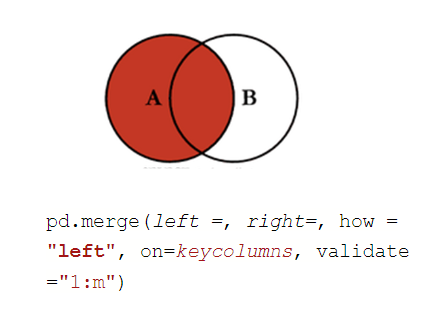

Suppose we want to merge the CUSTOMER and CUSTOMER_ORDER DataFrames, and the result table should **contain all the customers** regardless of whether they placed any order in the past.

We can accomplish this with a **LEFT JOIN** by specifying the parameter `how = "left"`.

In [57]:
pd.merge(left = CUSTOMER[["CUSTOMER_ID","NAME"]],
         right = CUSTOMER_ORDER,
         how = "left",
         left_on="CUSTOMER_ID",
         right_on="CUSTOMER_ID",
         validate ="1:m")

,CUSTOMER_ID,NAME,ORDER_ID,ORDER_DATE,SHIP_DATE,PRODUCT_ID,ORDER_QTY,SHIPPED
0,1,LITE Industrial,1.0,2015-05-15,2015-05-18,1.0,450.0,false
1,2,Rex Tooling Inc,NaN,NaN,NaN,NaN,NaN,NaN
2,3,Re-Barre Construction,2.0,2015-05-18,2015-05-21,2.0,600.0,false
3,3,Re-Barre Construction,3.0,2015-05-20,2015-05-23,5.0,300.0,false
4,3,Re-Barre Construction,5.0,2015-05-17,2015-05-20,2.0,500.0,false
5,4,Prairie Construction,NaN,NaN,NaN,NaN,NaN,NaN
6,5,Marsh Lane Metal Works,4.0,2015-05-18,2015-05-22,4.0,375.0,false


<font color="orange">**Practice Question**</font>

Find customers that have no orders.

Hint:

* Build the left join, filter for customers that have no orders.
* In another word, filter any field from the result table where the order_id is NAN.



In [66]:
# your turn.
merged = pd.merge(
    left=CUSTOMER[["CUSTOMER_ID", "NAME"]],
    right=CUSTOMER_ORDER,
    how="left",
    left_on="CUSTOMER_ID",
    right_on="CUSTOMER_ID",
    validate="1:m"
)

merged[merged["ORDER_ID"].isna()]

,CUSTOMER_ID,NAME,ORDER_ID,ORDER_DATE,SHIP_DATE,PRODUCT_ID,ORDER_QTY,SHIPPED
1,2,Rex Tooling Inc,NaN,NaN,NaN,NaN,NaN,NaN
5,4,Prairie Construction,NaN,NaN,NaN,NaN,NaN,NaN


### Right Join

RIGHT JOIN is almost identical to the left join, the only difference is that right join keeps all the unmatched key values in the right table.


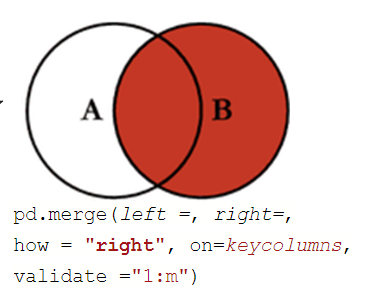

<font color="orange">**Practice Question**</font>

Use **right join** to merge the `CUSTOMER` and `CUSTOMER_ORDER` DataFrames, and the result table should contain all the customers regardless of whether they placed any order in the past.

In [80]:
# your turn.
pd.merge(
    CUSTOMER_ORDER,
    CUSTOMER,
    how="right",
    on="CUSTOMER_ID",
    validate="m:1"
)


,ORDER_ID,ORDER_DATE,SHIP_DATE,CUSTOMER_ID,PRODUCT_ID,ORDER_QTY,SHIPPED,NAME,REGION,STREET_ADDRESS,CITY,STATE,ZIP
0,1.0,2015-05-15,2015-05-18,1,1.0,450.0,false,LITE Industrial,Southwest,729 Ravine Way,Irving,TX,75014
1,NaN,NaN,NaN,2,NaN,NaN,NaN,Rex Tooling Inc,Southwest,6129 Collie Blvd,Dallas,TX,75201
2,2.0,2015-05-18,2015-05-21,3,2.0,600.0,false,Re-Barre Construction,Southwest,9043 Windy Dr,Irving,TX,75032
3,3.0,2015-05-20,2015-05-23,3,5.0,300.0,false,Re-Barre Construction,Southwest,9043 Windy Dr,Irving,TX,75032
4,5.0,2015-05-17,2015-05-20,3,2.0,500.0,false,Re-Barre Construction,Southwest,9043 Windy Dr,Irving,TX,75032
5,NaN,NaN,NaN,4,NaN,NaN,NaN,Prairie Construction,Southwest,264 Long Rd,Moore,OK,62104
6,4.0,2015-05-18,2015-05-22,5,4.0,375.0,false,Marsh Lane Metal Works,Southeast,9143 Marsh Ln,Avondale,LA,79782


### Outer Join

There also is a full outer join operator called OUTER JOIN that includes all records from both tables.
It does a LEFT JOIN and a RIGHT JOIN simultaneously, and can have null records in both tables.

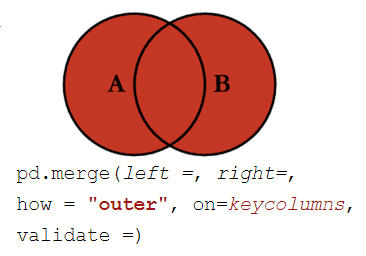

<font color="orange">**Practice Question**</font>

Given the DataFrame `df1` and `df2` below, merge them using outer join.

Can you predict the number of rows in the result table before running your Python code?

In [81]:
packages = {
    'Name':["Python","numpy","sqlite","pandas"],
    'Difficulty':['Hard','Intermediate','Intermediate','Easy'],
              }
df1 = pd.DataFrame(packages)

languages = {
    'Name':["Spark","Java","Python","Scala"],
    'LanguageType':["OOP","OOP","OOP","Functional Programming"]
              }
df2 = pd.DataFrame(languages)

In [82]:
df1

,Name,Difficulty
0,Python,Hard
1,numpy,Intermediate
2,sqlite,Intermediate
3,pandas,Easy


In [83]:
df2

,Name,LanguageType
0,Spark,OOP
1,Java,OOP
2,Python,OOP
3,Scala,Functional Programming


In [91]:
# your turn.
pd.merge(df1, df2, how="outer", on="Name")



,Name,Difficulty,LanguageType
0,Java,NaN,OOP
1,Python,Hard,OOP
2,Scala,NaN,Functional Programming
3,Spark,NaN,OOP
4,numpy,Intermediate,NaN
5,pandas,Easy,NaN
6,sqlite,Intermediate,NaN


### Cross Join

A cross join is a type of join that returns the **Cartesian product of rows from the tables in the join**.

In other words, it combines each row from the LEFT table with each row from the RIGHT table.

We don't usually specify the parameter "`validate = `" for cross join. Because they are often `"many_to_many"` relationship.  

In [92]:
df3 = pd.DataFrame({"Product": ["Shirt", "Leggings"]})
df4 = pd.DataFrame({"Color":["Red","Blue","Black"]})
df3

,Product
0,Shirt
1,Leggings


In [41]:
df4

,Color
0,Red
1,Blue
2,Black


In [96]:
# your turn:
pd.merge(df3, df4, how="cross")

# result table should return all the combination of rows from the DataFrames.
# guess the # of rows in the result table:




,Product,Color
0,Shirt,Red
1,Shirt,Blue
2,Shirt,Black
3,Leggings,Red
4,Leggings,Blue
5,Leggings,Black


### Special Case: Joins for `"many_to_many"` relationship

You will have a **cartesian product** of the matched "many to many" rows from both tables when you perform **inner/left/right/outer** joins for "many to many" relationships.

DataFrame `df5` and `df6` have "many_to_many" relationship when merging using the key column `id`, check the rows where `id = 2` in both DataFrames.



In [99]:
df5 = pd.DataFrame({"id":[1,2,2,3,4,7],"value_left":["A","B","C","D","E","F"]})
df6 = pd.DataFrame({"id":[1,2,2,3,5],"value_right":["X","Y","Z","Q","N"]})

In [100]:
df5

,id,value_left
0,1,A
1,2,B
2,2,C
3,3,D
4,4,E
5,7,F


In [45]:
df6

,id,value_right
0,1,X
1,2,Y
2,2,Z
3,3,Q
4,5,N


<font color="orange">**Practice Question**</font>

Given `df5` and `df6`, please answer the questions below without writing code.

* How many rows will be return if you do an inner join?
* How many rows will be return if you do an left join?
* How many rows will be return if you do an right join?
* How many rows will be return if you do an outer join?

**Edit this text cell to add your answers.**


In [131]:
# write code below to verify your answers:
pd.merge(df5, df6, how="inner", on="id")
print("A1. The number of rows in the result table is 6.")
pd.merge(left = df5[["id","value_left"]],
         right = df6,
         how = "left",
         left_on="id",
         right_on="id")
print("A2. The number of rows in the result table is 8.")
pd.merge(right = df6[["id","value_right"]],
         left = df5,
         how = "right",
         left_on="id",
         right_on="id")
print("A3. The number of rows in the result table is 7.")
pd.merge(df5, df6, how = "outer")
print("A4. The number of rows in the result table is 9.")

A1. The number of rows in the result table is 6.
A2. The number of rows in the result table is 8.
A3. The number of rows in the result table is 7.
A4. The number of rows in the result table is 9.


In [126]:
len(pd.merge(df5, df6, how="inner", on="id"))

6

In [127]:
len(pd.merge(df5, df6, how="left", on="id"))

8

In [128]:
len(pd.merge(df5, df6, how="right", on="id"))

7

In [129]:
len(pd.merge(df5, df6, how="outer", on="id"))

9

## <font color="orange">**Joins Practice using `df.merge()` and `df.join()`**

The **DataFrame functions** below also support joins. Unlike `pd.merge()` function, where both the left and right tables must be specified as parameter, you only need to specify the "right" table (`other=`) as the parameter in the DataFrame join functions below.

**Read the Pandas API Reference for these two functions, and use these two functions to answer coding questions below**:


* `DataFrame.merge(other)`: Merge DataFrame or named Series objects with a database-style join.
    * <https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.join.html>
* `Dataframe.join(other)`: Join columns of another DataFrame either on index or on a key columns.
    * https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.merge.html#pandas.DataFrame.merge

**Q1. Display the product name and order details in one result table.**

In [140]:
# your turn

products_with_orders = pd.merge(
    left = PRODUCT,
    right= CUSTOMER_ORDER,
    how="left",
    validate = "1:m")
products_with_orders

,PRODUCT_ID,DESCRIPTION,PRICE,ORDER_ID,ORDER_DATE,SHIP_DATE,CUSTOMER_ID,ORDER_QTY,SHIPPED
0,1,Copper,7.51,1.0,2015-05-15,2015-05-18,1.0,450.0,false
1,2,Aluminum,2.58,2.0,2015-05-18,2015-05-21,3.0,600.0,false
2,2,Aluminum,2.58,5.0,2015-05-17,2015-05-20,3.0,500.0,false
3,3,Silver,15.00,NaN,NaN,NaN,NaN,NaN,NaN
4,4,Steel,12.31,4.0,2015-05-18,2015-05-22,5.0,375.0,false
5,5,Bronze,4.00,3.0,2015-05-20,2015-05-23,3.0,300.0,false
6,6,Duralumin,7.60,NaN,NaN,NaN,NaN,NaN,NaN
7,7,Solder,14.16,NaN,NaN,NaN,NaN,NaN,NaN
8,8,Stellite,13.31,NaN,NaN,NaN,NaN,NaN,NaN
9,9,Brass,4.75,NaN,NaN,NaN,NaN,NaN,NaN


In [141]:
PRODUCT

,PRODUCT_ID,DESCRIPTION,PRICE
0,1,Copper,7.51
1,2,Aluminum,2.58
2,3,Silver,15.00
3,4,Steel,12.31
4,5,Bronze,4.00
5,6,Duralumin,7.60
6,7,Solder,14.16
7,8,Stellite,13.31
8,9,Brass,4.75


**Q2. Display the list of products without sales.**

In [142]:
# your turn

products_with_orders[products_with_orders["ORDER_ID"].isna()]


,PRODUCT_ID,DESCRIPTION,PRICE,ORDER_ID,ORDER_DATE,SHIP_DATE,CUSTOMER_ID,ORDER_QTY,SHIPPED
3,3,Silver,15.00,NaN,NaN,NaN,NaN,NaN,NaN
6,6,Duralumin,7.60,NaN,NaN,NaN,NaN,NaN,NaN
7,7,Solder,14.16,NaN,NaN,NaN,NaN,NaN,NaN
8,8,Stellite,13.31,NaN,NaN,NaN,NaN,NaN,NaN
9,9,Brass,4.75,NaN,NaN,NaN,NaN,NaN,NaN


**Q3. Display the top 3 best-selling products.**

The result table should have the following columns:
* product_id, product name, sales.

Sales = Price (in PRODUCT DataFrame) * Quantity (CUSTOMER_ORDER DataFrame)


In [ ]:
# your turn




**Q4. Display the customer name, product name, and order details in one result table.**

Hint: You need to join multiple tables.

In [ ]:
# your turn



**Q5. Calculate the sales per customer.**

Continued with the Q3, the result table for Q4 should display three columns:
* customer_id, customer's name, and sales.

Sales = Price (in PRODUCT DataFrame) * Quantity (CUSTOMER_ORDER DataFrame)


In [ ]:
# your turn.




# **Commit and push your completed notebook to GitHub.**